# 03 regional structural inequality

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import StandardScaler

data_path = '/Users/sophialiu/Downloads/Data-Covid003.csv'
var_desc_path = '/Users/sophialiu/Downloads/PPHA_30545_MP03-Variable_Description.xlsx'

In [6]:
!pip install openpyxl

df = pd.read_csv(data_path, encoding='latin1')
var_desc = pd.read_excel(var_desc_path)

# Identify Opportunity Insights and PM COVID variables
oi_pm_mask = var_desc['Source'].isin(['Opportunity Insights', 'PM COVID'])
oi_pm_vars = var_desc.loc[oi_pm_mask, 'Variable'].tolist()

# Variables to keep (plus county, state, deathspc)
vars_to_keep = list(set(oi_pm_vars + ['county', 'state', 'deathspc']))
df_sub = df[vars_to_keep].copy()

df_sub.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [openpyxl]1/2 [openpyxl]


,state,intersects_msa,frac_traveltime_lt15,cs00_seg_inc_pov25,poor_share,bmi_obese_q3,exercise_any_q1,scap_ski90pcm,cs00_seg_inc_aff75,cur_smoke_q1,...,score_r,taxrate,bmi_obese_q4,diab_lipids_10,gini99,pop_density,diab_eyeexam_10,tax_st_diff_top20,cs_frac_black,deathspc
0,Alabama,1,0.233124,0.043313,0.109228,0.260870,0.500000,-0.897834,0.037231,0.333333,...,-7.308133,0.011183,0.133333,83.925550,0.379976,73.277412,72.419628,0.0,17.008999,0.544371
1,Alabama,1,0.295529,0.021566,0.101471,0.193237,0.599432,-0.362414,0.041103,0.268097,...,-13.628747,0.011756,0.135747,78.992314,0.489738,87.960236,64.047822,0.0,10.224691,0.290043
2,Alabama,0,0.394128,0.021777,0.267998,0.545455,0.542857,-1.499349,0.020898,0.228571,...,-15.955111,0.012059,0.277778,81.519507,0.490637,32.814877,67.556468,0.0,46.039669,0.200296
3,Alabama,1,0.246582,0.028094,0.206075,0.190476,0.422222,-0.930472,0.002048,0.244444,...,-14.839100,0.008007,0.100000,80.528053,0.417098,33.427227,64.356436,0.0,22.010948,0.251591
4,Alabama,1,0.213904,0.015049,0.117428,0.529412,0.565217,-1.304095,0.013171,0.304348,...,-10.218139,0.007012,0.235294,79.223301,0.333042,79.035255,68.155340,0.0,1.171997,0.100248


## 2. Summary statistics

In [7]:
# Summary statistics for deathspc and selected variables
df_sub.describe().T

,count,mean,std,min,25%,50%,75%,max
intersects_msa,3107.0,0.596717,0.490636,0.000000,0.000000,1.000000,1.000000,1.000000e+00
frac_traveltime_lt15,3107.0,0.403803,0.137215,0.099878,0.299927,0.385816,0.499088,8.176365e-01
cs00_seg_inc_pov25,3107.0,0.024278,0.030757,-0.019502,0.004164,0.013136,0.034737,7.491062e-01
poor_share,3107.0,0.141739,0.065460,0.000000,0.095383,0.129621,0.175282,5.691699e-01
bmi_obese_q3,3107.0,0.209621,0.175849,0.000000,0.000000,0.223124,0.297220,1.000000e+00
exercise_any_q1,3107.0,0.455995,0.273874,0.000000,0.312500,0.566563,0.641509,1.000000e+00
scap_ski90pcm,3107.0,0.000182,1.347960,-4.258739,-0.964225,-0.091105,0.818039,9.911112e+00
cs00_seg_inc_aff75,3107.0,0.026463,0.032920,-0.001993,0.003455,0.012577,0.037337,1.969586e-01
cur_smoke_q1,3107.0,0.212659,0.149348,0.000000,0.000000,0.250000,0.310931,1.000000e+00
mammogram_10,3029.0,63.110073,8.397699,30.000000,57.943925,63.618290,68.907563,9.523810e+01


## 3. Cleaning data and creating state dummies

In [8]:
# Drop missing values
df_clean = df_sub.dropna()

# Create state dummies
state_dummies = pd.get_dummies(df_clean['state'], prefix='state')

# Combine and drop non-numeric identifiers
df_model = pd.concat([df_clean.drop(columns=['state', 'county']), state_dummies], axis=1)
df_model.head()

,intersects_msa,frac_traveltime_lt15,cs00_seg_inc_pov25,poor_share,bmi_obese_q3,exercise_any_q1,scap_ski90pcm,cs00_seg_inc_aff75,cur_smoke_q1,mammogram_10,...,state_South Dakota,state_Tennessee,state_Texas,state_Utah,state_Vermont,state_Virginia,state_Washington,state_West Virginia,state_Wisconsin,state_Wyoming
0,1,0.233124,0.043313,0.109228,0.260870,0.500000,-0.897834,0.037231,0.333333,68.465909,...,False,False,False,False,False,False,False,False,False,False
1,1,0.295529,0.021566,0.101471,0.193237,0.599432,-0.362414,0.041103,0.268097,69.873998,...,False,False,False,False,False,False,False,False,False,False
2,0,0.394128,0.021777,0.267998,0.545455,0.542857,-1.499349,0.020898,0.228571,64.768683,...,False,False,False,False,False,False,False,False,False,False
3,1,0.246582,0.028094,0.206075,0.190476,0.422222,-0.930472,0.002048,0.244444,57.228916,...,False,False,False,False,False,False,False,False,False,False
4,1,0.213904,0.015049,0.117428,0.529412,0.565217,-1.304095,0.013171,0.304348,66.025641,...,False,False,False,False,False,False,False,False,False,False


## 4. Train-test split and OLS baseline model

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

y = df_model['deathspc'].values
X = df_model.drop(columns=['deathspc']).values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=11
)

ols_model = LinearRegression()
ols_model.fit(X_train, y_train)

y_train_pred_ols = ols_model.predict(X_train)
y_test_pred_ols = ols_model.predict(X_test)

mse_train_ols = mean_squared_error(y_train, y_train_pred_ols)
mse_test_ols = mean_squared_error(y_test, y_test_pred_ols)

mse_train_ols, mse_test_ols

(1.291531362885238, 1.823783555706794)

## 5. Ridge and Lasso with cross-validation

In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, cross_val_score
from sklearn.linear_model import Ridge, Lasso

# Scale predictors
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 5-fold CV (using 5 here for computational simplicity)
kfold = KFold(n_splits=5, shuffle=True, random_state=25)

# Ridge
alphas_ridge = np.logspace(-2, 2, 10)
ridge_cv_mse = []

for a in alphas_ridge:
    ridge_model = Ridge(alpha=a, random_state=25)
    scores = cross_val_score(
        ridge_model, X_train_scaled, y_train,
        cv=kfold, scoring='neg_mean_squared_error'
    )
    ridge_cv_mse.append(-scores.mean())

ridge_cv_mse = np.array(ridge_cv_mse)
ridge_best_index = np.argmin(ridge_cv_mse)
ridge_best_alpha = alphas_ridge[ridge_best_index]

ridge_best = Ridge(alpha=ridge_best_alpha, random_state=25)
ridge_best.fit(X_train_scaled, y_train)

y_train_pred_ridge = ridge_best.predict(X_train_scaled)
y_test_pred_ridge = ridge_best.predict(X_test_scaled)

mse_train_ridge = mean_squared_error(y_train, y_train_pred_ridge)
mse_test_ridge = mean_squared_error(y_test, y_test_pred_ridge)

ridge_best_alpha, mse_train_ridge, mse_test_ridge

(np.float64(100.0), 1.2961162198641356, 1.8200977373157354)

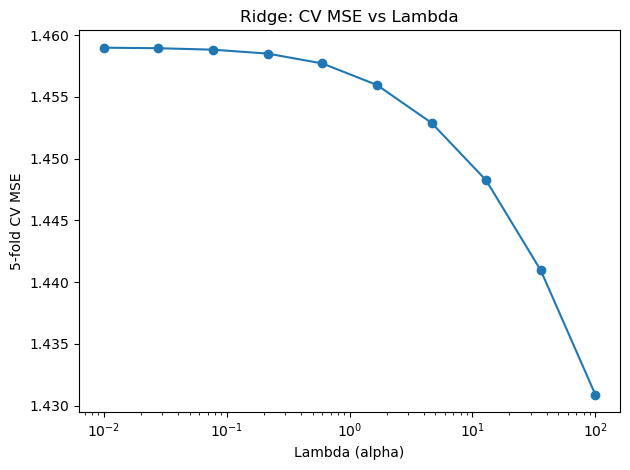

In [11]:
plt.figure()
plt.plot(alphas_ridge, ridge_cv_mse, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('5-fold CV MSE')
plt.title('Ridge: CV MSE vs Lambda')
plt.tight_layout()
plt.show()

In [12]:
# Lasso
alphas_lasso = np.logspace(-3, 1, 10)
lasso_cv_mse = []

for a in alphas_lasso:
    lasso_model = Lasso(alpha=a, random_state=25, max_iter=5000)
    scores = cross_val_score(
        lasso_model, X_train_scaled, y_train,
        cv=kfold, scoring='neg_mean_squared_error'
    )
    lasso_cv_mse.append(-scores.mean())

lasso_cv_mse = np.array(lasso_cv_mse)
lasso_best_index = np.argmin(lasso_cv_mse)
lasso_best_alpha = alphas_lasso[lasso_best_index]

lasso_best = Lasso(alpha=lasso_best_alpha, random_state=25, max_iter=5000)
lasso_best.fit(X_train_scaled, y_train)

y_train_pred_lasso = lasso_best.predict(X_train_scaled)
y_test_pred_lasso = lasso_best.predict(X_test_scaled)

mse_train_lasso = mean_squared_error(y_train, y_train_pred_lasso)
mse_test_lasso = mean_squared_error(y_test, y_test_pred_lasso)

lasso_best_alpha, mse_train_lasso, mse_test_lasso

(np.float64(0.007742636826811269), 1.305848583257012, 1.8051819202290176)

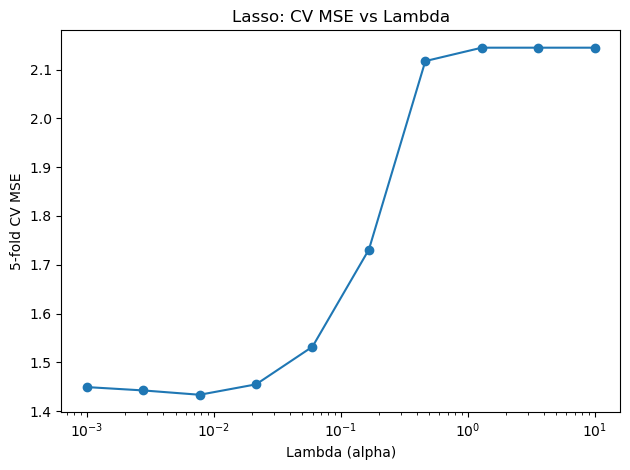

In [13]:
plt.figure()
plt.plot(alphas_lasso, lasso_cv_mse, marker='o')
plt.xscale('log')
plt.xlabel('Lambda (alpha)')
plt.ylabel('5-fold CV MSE')
plt.title('Lasso: CV MSE vs Lambda')
plt.tight_layout()
plt.show()

## 6. Model comparison and recommendation

Across the three models, OLS exhibits the highest test-set MSE (≈1.824), indicating limited generalization when predicting COVID-19 deaths per capita. Both regularized models improve upon OLS: ridge regression reduces the test MSE slightly (≈1.820), while lasso achieves the best performance with the lowest test MSE (≈1.805).
The regularization in ridge and lasso increases bias but substantially reduces variance, helping prevent overfitting. This is reflected in their narrower gaps between training and test errors relative to OLS. In addition, lasso shrinks many coefficients exactly to zero, retaining only 80 non-zero predictors. This feature selection property both simplifies the model and enhances interpretability for policymakers.
Recommendation:
I recommend the lasso model to the CDC. It provides the lowest predictive error, stronger generalization, and a more interpretable set of predictors, allowing the agency to identify the most influential county-level characteristics while avoiding unnecessary model complexity. Ridge improves over OLS but lacks the interpretability benefits of lasso, making lasso the preferred choice overall.